### Imports

In [1]:
from datetime import date
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Define timeframe for stock data

In [2]:
end = date.today()
start = end.replace(
    year=end.year - 5,
    day = min(end.day, 28) if end.month == 2 else end.day
)

start_date = start.strftime("%Y-%m-%d")
end_date = end.strftime("%Y-%m-%d")

### Fetch and clean stock data

In [3]:
def get_stock_data(ticker):
    data = yf.download(ticker, start_date, end_date)
    return data

df = get_stock_data("NVDA")
df.reset_index(inplace=True)
df.columns = df.columns.get_level_values(0)
df.columns.name = None
df.head()

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2021-03-23,13.037890,13.310952,12.988514,13.220928,222048000
1,2021-03-24,12.611217,13.126169,12.604983,13.118189,245840000
2,2021-03-25,12.503736,12.682785,12.241148,12.468076,295144000
3,2021-03-26,12.806971,12.823928,12.342392,12.522936,363968000
4,2021-03-29,12.915698,13.029661,12.668072,12.788020,273520000


### Plot stock data

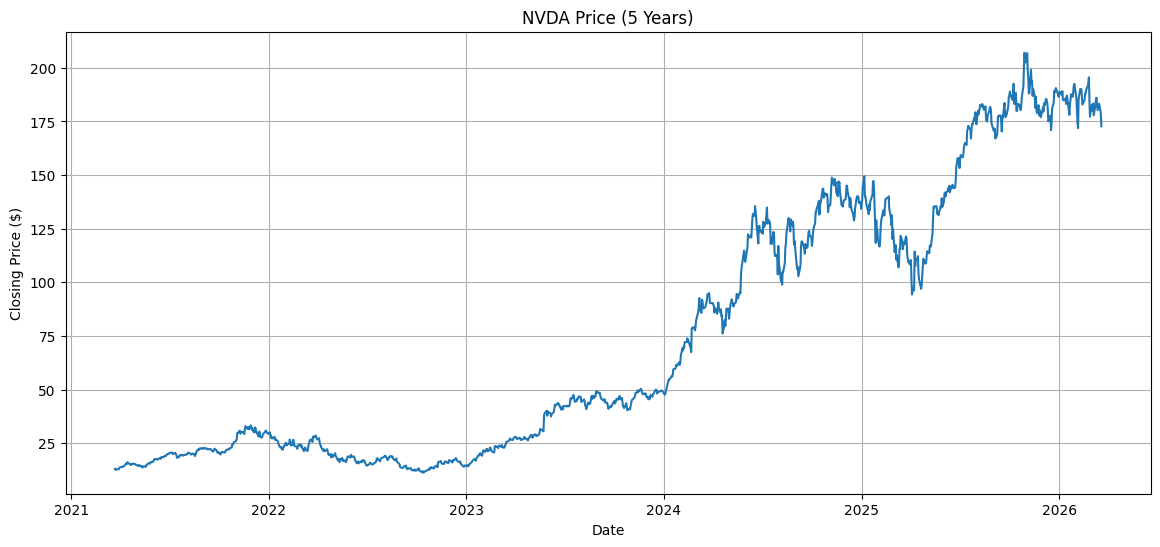

In [4]:
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.title("NVDA Price (5 Years)")
plt.show()

### Plot the 9, 21, and 100 EMAs

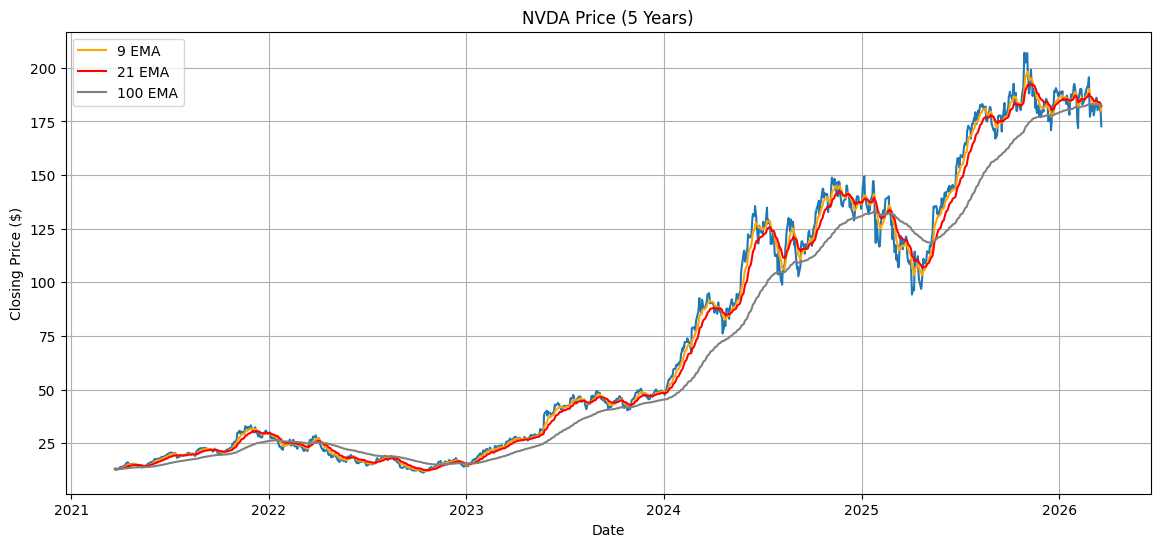

In [5]:
# Calculate EMAs
df["ema9"] = df["Close"].ewm(span=9, adjust=False).mean()
df["ema21"] = df["Close"].ewm(span=21, adjust=False).mean()
df["ema100"] = df["Close"].ewm(span=100, adjust=False).mean()

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.title("NVDA Price (5 Years)")

# Plot EMAs
plt.plot(df["Date"], df["ema9"], label="9 EMA", color="orange")
plt.plot(df["Date"], df["ema21"], label="21 EMA", color="red")
plt.plot(df["Date"], df["ema100"], label="100 EMA", color="gray")
plt.legend()

### Use an 80/20 train/test split

In [6]:
df.shape

(1255, 9)

In [7]:
split = int(len(df) * 0.8)
train = df[:split]
test = df[split:]

In [8]:
print(train.shape)
train.head()

(1004, 9)


,Date,Close,High,Low,Open,Volume,ema9,ema21,ema100
0,2021-03-23,13.037890,13.310952,12.988514,13.220928,222048000,13.037890,13.037890,13.037890
1,2021-03-24,12.611217,13.126169,12.604983,13.118189,245840000,12.952556,12.999102,13.029441
2,2021-03-25,12.503736,12.682785,12.241148,12.468076,295144000,12.862792,12.954069,13.019031
3,2021-03-26,12.806971,12.823928,12.342392,12.522936,363968000,12.851627,12.940696,13.014832
4,2021-03-29,12.915698,13.029661,12.668072,12.788020,273520000,12.864442,12.938424,13.012869


In [9]:
print(test.shape)
test.head()

(251, 9)


,Date,Close,High,Low,Open,Volume,ema9,ema21,ema100
1004,2025-03-21,117.672264,117.962197,115.392803,116.912449,266498500,117.290448,119.532422,127.400671
1005,2025-03-24,121.381401,122.191208,119.311881,119.851755,228452500,118.108638,119.700511,127.281477
1006,2025-03-25,120.661568,121.261425,118.891980,120.521601,167447200,118.619224,119.787880,127.150390
1007,2025-03-26,113.733200,118.811997,112.683444,118.702030,293463300,117.642019,119.237455,126.884703
1008,2025-03-27,111.403755,114.423041,110.633940,111.323772,236902100,116.394367,118.525300,126.578150


### Normalize the dataset

In [10]:
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler has default param feature_range=(0,1)
scaler = MinMaxScaler()

train_close = train[["Close"]]
test_close = test[["Close"]]

# Scale training data
train_close_scaled = scaler.fit_transform(train_close)

# Scale testing data
prev_100_close = train_close.tail(100)
test_close = pd.concat([prev_100_close, test_close], ignore_index=True)
test_close_scaled = scaler.transform(test_close)

In [11]:
train_close_scaled

array([[0.01321279],
       [0.01012472],
       [0.00934682],
       ...,
       [0.75408157],
       [0.76920444],
       [0.77651259]], shape=(1004, 1))

In [12]:
test_close_scaled

array([[0.934669  ],
       [0.94284412],
       [0.93546491],
       [0.94074606],
       [0.92692788],
       [0.87932383],
       [0.89842338],
       [0.90312596],
       [0.93105167],
       [0.97228931],
       [0.99594656],
       [0.98690319],
       [0.96975702],
       [0.99167788],
       [0.97706423],
       [0.98060911],
       [0.94602733],
       [0.93278783],
       [0.98241772],
       [0.97431493],
       [0.97995798],
       [0.94581043],
       [0.90290885],
       [0.90942004],
       [0.89798915],
       [0.91904221],
       [0.92179129],
       [0.93358385],
       [0.96888888],
       [0.96838253],
       [0.94942643],
       [0.92316268],
       [0.89610324],
       [0.92678023],
       [0.91252704],
       [0.8901704 ],
       [0.87389137],
       [0.86224271],
       [0.85153473],
       [0.86434077],
       [0.89342616],
       [0.92938497],
       [0.93336442],
       [0.93126613],
       [0.91013931],
       [0.91361229],
       [0.89045985],
       [0.919

### Create training sequences

In [13]:
x_train = []
y_train = []

# For each price x, grab the 100 prices before it and add them as a singular (list) element to x_train. Add price x as an element to y_train.
for i in range(100, train_close_scaled.shape[0]):
    x_train.append(train_close_scaled[i - 100 : i])
    y_train.append(train_close_scaled[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

print(x_train.shape)
print(y_train.shape)

(904, 100, 1)
(904,)


### Create testing sequences

In [14]:
x_test = []
y_test = []

for i in range(100, test_close_scaled.shape[0]):
    x_test.append(test_close_scaled[i - 100 : i])
    y_test.append(test_close_scaled[i, 0])

x_test = np.array(x_test)
y_test = np.array(y_test)

print(x_test.shape)
print(y_test.shape)

(251, 100, 1)
(251,)
